## ИИММ: практическая работа 4

Суть задания:

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала.
Персонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.

План работы:
1. Подготовка
2. Загрузка и обработка данных
3. Построение нейросети
4. Функции для работы с моделью
5. Применение модели к данным
6. Улучшение Score
7. Submit на Kaggle

### Этап 1. Подготовка

In [5]:
import torch
import numpy as np

import pickle
import numpy as np
import time, os, gc
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from torchvision.transforms import v2

import torchsummary

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

In [6]:
!python --version
from importlib.metadata import version
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ version(b))

Python 3.13.7
torch version: 2.8.0+cu126
torchvision version: 0.23.0+cu126
tqdm version: 4.67.1
matplotlib version: 3.10.0
seaborn version: 0.13.2
Pillow version: 11.3.0


In [7]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']

# работаем на видеокарте
DEVICE = torch.device("cuda")

# определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('content/train') #Path('./data/train/')
TEST_DIR = Path('content/testset') #Path('./data/testset')

# параметры нормировки изображений по трем каналам перед подачей в модель
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = [224, 224]

### Этап 2. Загрузка и обработка данных

In [8]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))
train_val_files[:10]

[WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0000.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0001.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0002.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0003.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0004.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0005.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0006.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0007.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0008.jpg'),
 WindowsPath('content/train/simpsons_dataset/abraham_grampa_simpson/pic_0009.jpg')]

In [9]:
label_encoder = LabelEncoder()

train_val_labels = [path.parent.name for path in train_val_files]

label_encoder.fit(train_val_labels)

LabelEncoder()

In [10]:
train_val_labels[:10]

['abraham_grampa_simpson',
 'abraham_grampa_simpson',
 'abraham_grampa_simpson',
 'abraham_grampa_simpson',
 'abraham_grampa_simpson',
 'abraham_grampa_simpson',
 'abraham_grampa_simpson',
 'abraham_grampa_simpson',
 'abraham_grampa_simpson',
 'abraham_grampa_simpson']

In [11]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

In [12]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_ # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.
        # Если вы решите перевзвесить размеры категорий внутри класса -
        # не забудьте изменить вывод self.__len__()

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.RandomHorizontalFlip(),   # Добавляю для улучшения
            v2.ToDtype(torch.float32, scale=True),
            v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2), # Добавляю для улучшения
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])
      else:
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)


In [13]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

In [14]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Числовая метка класса: 37
Текстовая метка класса: ['sideshow_bob']


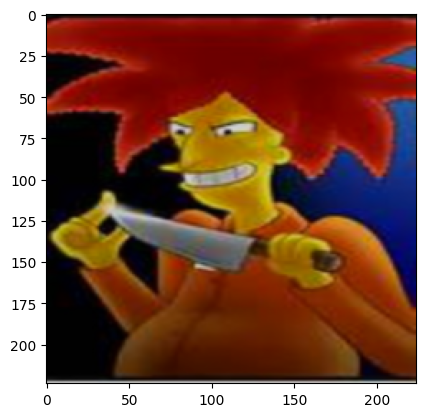

In [15]:
image_tensor, label = next(iter(train_loader))
print(f"Числовая метка класса: {label[0]}")
print(f"Текстовая метка класса: {label_encoder.inverse_transform([label[0],])}")
imshow(image_tensor[0])

In [16]:
def show_images(n_rows, n_cols, dataset):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in ax.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # получаем изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()
    fig_x.set_axis_off()
  return None

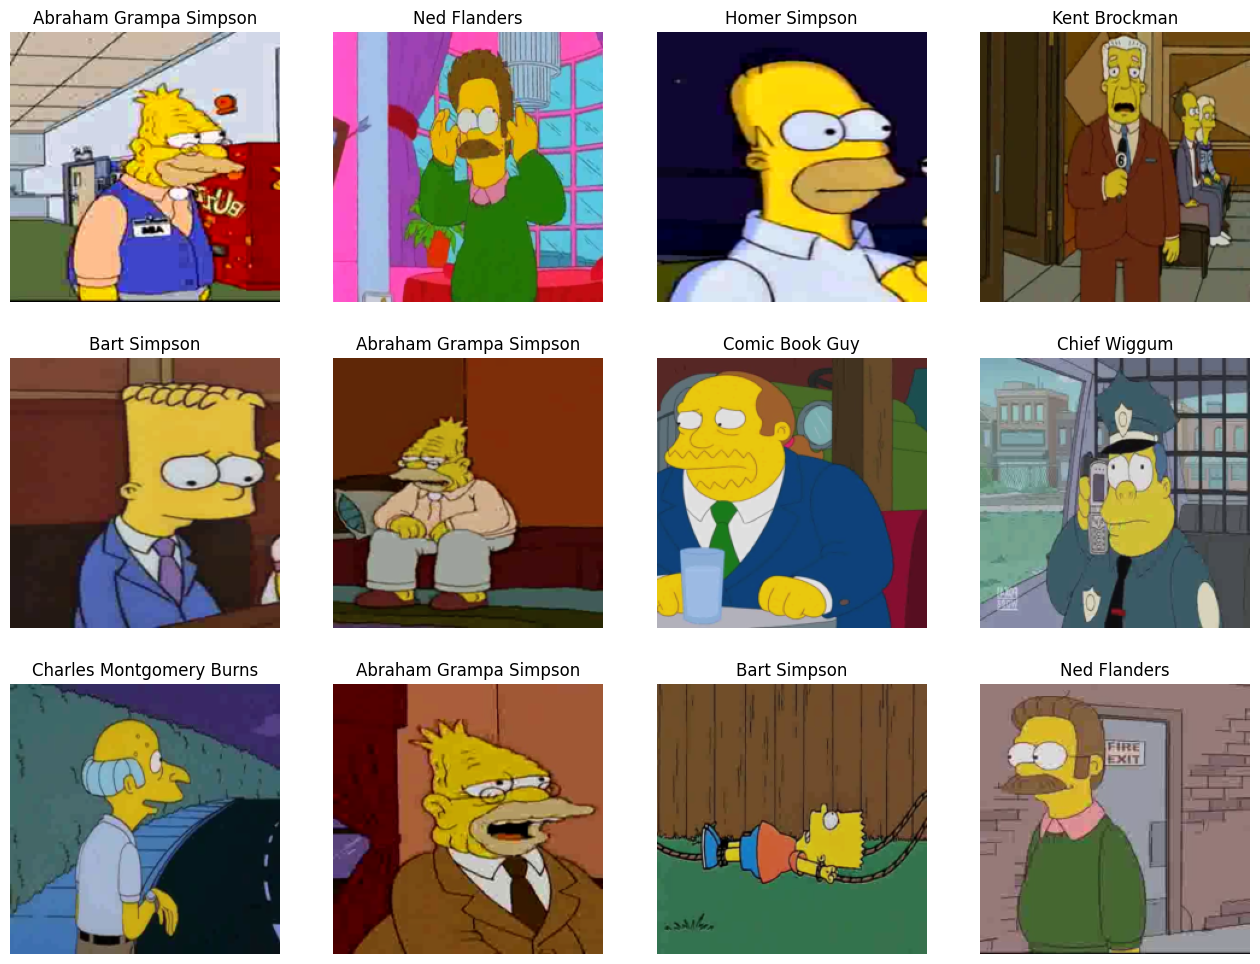

In [17]:
show_images(n_rows = 3, n_cols = 4, dataset = train_dataset)

### Этап 3. Построение нейросети

In [18]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

In [19]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
         MaxPool2d-3          [-1, 8, 111, 111]               0
            Conv2d-4         [-1, 16, 109, 109]           1,168
              ReLU-5         [-1, 16, 109, 109]               0
         MaxPool2d-6           [-1, 16, 54, 54]               0
            Conv2d-7           [-1, 32, 52, 52]           4,640
              ReLU-8           [-1, 32, 52, 52]               0
         MaxPool2d-9           [-1, 32, 26, 26]               0
           Conv2d-10           [-1, 64, 24, 24]          18,496
             ReLU-11           [-1, 64, 24, 24]               0
        MaxPool2d-12           [-1, 64, 12, 12]               0
           Conv2d-13           [-1, 96, 10, 10]          55,392
             ReLU-14           [-1, 96,

In [20]:
# Обучение модели на одной эпохе

def train_epoch(model, train_loader, criterion,  optimizer):
    actual_labels = []; y_predicted = []
    for inputs, labels in tqdm(train_loader, leave=False):
        inputs = inputs.to(DEVICE); labels = labels.to(DEVICE)
        optimizer.zero_grad()
        scores = model(inputs)
        loss = criterion(scores, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(scores, dim=1)
        y_predicted.append(preds.detach().cpu().numpy())
        actual_labels.append(labels.detach().cpu().numpy())
        del inputs, labels, scores, loss, preds
    y_predicted = np.concatenate(y_predicted, axis=0)
    actual_labels = np.concatenate(actual_labels, axis=0)
    
    return actual_labels, y_predicted


In [21]:
# Валидация модели на одной эпохе

def validate_epoch(model, val_loader):
    actual_labels = []; y_predicted = []
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, leave=False):
            inputs = inputs.to(DEVICE); labels = labels.to(DEVICE)
            scores = model(inputs)
            preds = torch.argmax(scores, dim=1)
            y_predicted.append(preds.cpu().numpy())
            actual_labels.append(labels.cpu().numpy())
            del inputs, labels, scores, preds
    y_predicted = np.concatenate(y_predicted, axis=0)
    actual_labels = np.concatenate(actual_labels, axis=0)
    
    return actual_labels, y_predicted

In [22]:
# Обучение на эпохах

def train(model, train_loader, val_loader, num_epochs, criterion, optimizer, path=None, scheduler=None):
    print('Beginning to train model')
    if path and not os.path.exists(path):
      os.makedirs(path)
    model.to(DEVICE)
    res_train = []
    res_val = []

    for epoch in tqdm(range(1, num_epochs+1)):
        model.train()
        start_time = time.perf_counter()
        train_labels, train_preds = train_epoch(model, train_loader, criterion, optimizer)
        if path:
          torch.save(model.state_dict(), f'{path}/model_ep_{epoch:02d}.pth')
        end_time = time.perf_counter()
        duration = end_time - start_time
        model.eval()
        val_labels, val_preds = validate_epoch(model, val_loader)
        
        train_f1 = f1_score(train_labels, train_preds, average='micro')
        val_f1 = f1_score(val_labels, val_preds, average='micro')


        res_train.append(train_f1)
        res_val.append(val_f1)

        current_lr = optimizer.param_groups[0]['lr']

        if scheduler and current_lr > 5e-5:
            scheduler.step()
        
        print(f'epoch {epoch:2}',
              f'time: {duration:.3f}',
              f'train acc: {train_f1:.4f}',
              f'val acc: {val_f1:.4f}', sep='\t')
        
        del train_labels, train_preds, val_labels, val_preds
        
    return res_train, res_val


In [2]:
def metrics(train_accs, val_accs):
    epochs = range(1, len(train_accs) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot()
    plt.plot(epochs, train_accs, 'b', label='Training accuracy')
    plt.plot(epochs, val_accs, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### Этап 5. Применение модели к данным

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 1e-3)


In [ ]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
DEVICE

In [ ]:
num_epochs = 5
res_train, res_val = train(model_simple_cnn, train_loader, val_loader, num_epochs, criterion, optimizer, 'checkpoints', scheduler=scheduler)

In [ ]:
metrics(res_train, res_val)

### Этап 6. Улучшение score

In [26]:
class MyCnn(nn.Module):

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.sigm1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(32, 32//16, 1), nn.ReLU(True),
            nn.Conv2d(32//16, 32, 1), nn.Sigmoid())
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.sigm2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(256, 2, 1), nn.ReLU(True),
            nn.Conv2d(2, 256, 1), nn.Sigmoid())
        self.conv7 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv8 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten()
        )

        self.out = nn.Linear(1024, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x*self.sigm1(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = x*self.sigm2(x)
        x = self.conv7(x)
        x = self.conv8(x)
        logits = self.out(x)
        return logits

In [36]:
model_my_cnn = MyCnn(n_classes = len(np.unique(train_val_labels)))
model_my_cnn.to(DEVICE)
torchsummary.summary(model_my_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 224, 224]             224
       BatchNorm2d-2          [-1, 8, 224, 224]              16
              ReLU-3          [-1, 8, 224, 224]               0
         MaxPool2d-4          [-1, 8, 112, 112]               0
            Conv2d-5         [-1, 16, 112, 112]           1,168
       BatchNorm2d-6         [-1, 16, 112, 112]              32
              ReLU-7         [-1, 16, 112, 112]               0
         MaxPool2d-8           [-1, 16, 56, 56]               0
            Conv2d-9           [-1, 32, 56, 56]           4,640
      BatchNorm2d-10           [-1, 32, 56, 56]              64
             ReLU-11           [-1, 32, 56, 56]               0
        MaxPool2d-12           [-1, 32, 28, 28]               0
AdaptiveAvgPool2d-13             [-1, 32, 1, 1]               0
           Conv2d-14              [-1, 

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_my_cnn.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [38]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [39]:
num_epochs = 50
res_train, res_val = train(model_my_cnn, train_loader, val_loader, num_epochs, criterion, optimizer, 'checkpoints_my', scheduler=scheduler)

Beginning to train model


  2%|▏         | 1/50 [05:21<4:22:57, 322.00s/it]

epoch  1	time: 252.286	train acc: 0.5319	val acc: 0.6364


  4%|▍         | 2/50 [08:53<3:25:42, 257.13s/it]

epoch  2	time: 176.394	train acc: 0.7465	val acc: 0.7711


  6%|▌         | 3/50 [12:26<3:05:29, 236.79s/it]

epoch  3	time: 176.538	train acc: 0.8234	val acc: 0.7730


  8%|▊         | 4/50 [15:29<2:45:22, 215.70s/it]

epoch  4	time: 155.782	train acc: 0.8588	val acc: 0.7763


 10%|█         | 5/50 [18:20<2:29:43, 199.64s/it]

epoch  5	time: 143.777	train acc: 0.8909	val acc: 0.8573


 12%|█▏        | 6/50 [20:59<2:16:04, 185.55s/it]

epoch  6	time: 131.545	train acc: 0.9108	val acc: 0.8393


 14%|█▍        | 7/50 [23:35<2:06:03, 175.89s/it]

epoch  7	time: 129.807	train acc: 0.9313	val acc: 0.8464


 16%|█▌        | 8/50 [26:56<2:08:45, 183.94s/it]

epoch  8	time: 165.100	train acc: 0.9367	val acc: 0.8653


 18%|█▊        | 9/50 [30:21<2:10:18, 190.69s/it]

epoch  9	time: 169.373	train acc: 0.9539	val acc: 0.8750


 20%|██        | 10/50 [33:46<2:09:58, 194.96s/it]

epoch 10	time: 169.042	train acc: 0.9556	val acc: 0.8592


 22%|██▏       | 11/50 [37:09<2:08:25, 197.57s/it]

epoch 11	time: 168.266	train acc: 0.9831	val acc: 0.9201


 24%|██▍       | 12/50 [40:18<2:03:28, 194.95s/it]

epoch 12	time: 153.900	train acc: 0.9904	val acc: 0.9243


 26%|██▌       | 13/50 [43:41<2:01:39, 197.27s/it]

epoch 13	time: 166.831	train acc: 0.9941	val acc: 0.9263


 28%|██▊       | 14/50 [47:03<1:59:16, 198.79s/it]

epoch 14	time: 166.595	train acc: 0.9951	val acc: 0.9272


 30%|███       | 15/50 [50:11<1:54:06, 195.60s/it]

epoch 15	time: 161.117	train acc: 0.9957	val acc: 0.9289


 32%|███▏      | 16/50 [52:50<1:44:31, 184.45s/it]

epoch 16	time: 130.392	train acc: 0.9970	val acc: 0.9289


 34%|███▍      | 17/50 [55:27<1:36:56, 176.25s/it]

epoch 17	time: 129.710	train acc: 0.9980	val acc: 0.9297


 36%|███▌      | 18/50 [58:48<1:37:56, 183.64s/it]

epoch 18	time: 165.515	train acc: 0.9983	val acc: 0.9308


 38%|███▊      | 19/50 [1:02:09<1:37:35, 188.90s/it]

epoch 19	time: 165.943	train acc: 0.9984	val acc: 0.9282


 40%|████      | 20/50 [1:05:32<1:36:32, 193.07s/it]

epoch 20	time: 166.951	train acc: 0.9989	val acc: 0.9310


 40%|████      | 20/50 [1:07:39<1:41:29, 203.00s/it]


KeyboardInterrupt: 

In [39]:
model = MyCnn(n_classes = len(np.unique(train_val_labels)))
model.to(DEVICE)
model.load_state_dict(torch.load('checkpoints_my/model_ep_20.pth', map_location=torch.device('cuda')))

<All keys matched successfully>

In [40]:
model.eval()
val_labels, val_preds = validate_epoch(model, val_loader)
val_f1 = f1_score(val_labels, val_preds, average='micro')
print(f'val acc: {val_f1:.4f}', sep='\t')

val acc: 0.9828


In [41]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [42]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")
    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

In [44]:
predicted_numeric_labels = predict(model, test_loader)
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

In [45]:
import pandas as pd
sample_submission = pd.read_csv("./content/sample_submission.csv")
sample_submission.head(10)

,Id,Expected
0,img0.jpg,bart_simpson
1,img1.jpg,bart_simpson
2,img2.jpg,bart_simpson
3,img3.jpg,bart_simpson
4,img4.jpg,bart_simpson
5,img5.jpg,bart_simpson
6,img6.jpg,bart_simpson
7,img7.jpg,bart_simpson
8,img8.jpg,bart_simpson
9,img9.jpg,bart_simpson


In [46]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [47]:
my_submission.to_csv('my_cnn_baseline.csv', index=False)